In [1]:
import numpy as np
from matplotlib.pyplot import axis
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris
from sklearn.metrics import classification_report
X,y = load_iris(return_X_y=True)
tlu = Perceptron()
tlu.fit(X, y)
y_pred=tlu.predict(X)
print(classification_report(y, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.18      0.31        50
           1       0.39      1.00      0.56        50
           2       1.00      0.26      0.41        50

    accuracy                           0.48       150
   macro avg       0.80      0.48      0.43       150
weighted avg       0.80      0.48      0.43       150



In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# course title material

### Part 1 — TensorFlow
At the basic level, TensorFlow works with tensors.

A tensor is essentially an n-dimensional array.


In [75]:
import tensorflow as tf
x = tf.constant([[1,2,3],[4,5,6]])
print(x.shape)
print(x.dtype)

(2, 3)
<dtype: 'int32'>


## 2. How TensorFlow works
Data
 ↓
Tensor operations
 ↓
Model
 ↓
Prediction
 ↓
Loss
 ↓
Gradient
 ↓
Update weights
 ↓
repeat

In [92]:
x = tf.constant(3)
w = tf.Variable(2)

y = w * x
print(y)

x2 = tf.constant([[1,2,3],[4,5,6]])
w2 = tf.Variable(3)

y2 = x2 * w2
y2


tf.Tensor(6, shape=(), dtype=int32)


<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
array([[ 3,  6,  9],
       [12, 15, 18]])>

## 3. TensorFlow variables

constant VS Variable

Constant: You don't normally modify it.

Variables are designed to be updated.

Neural-network weights are variables.

old weights

     ↓

gradient

     ↓
optimizer

     ↓
new weights

## 4. TensorFlow GradientTape

This is much more important for modern TensorFlow than old Session.


because modern TensorFlow uses it heavily.


In [96]:
x = tf.Variable(3.0)
with tf.GradientTape() as tape:
    y = x ** 2

gradient = tape.gradient(y, x)
print(gradient)

tf.Tensor(6.0, shape=(), dtype=float32)



Mathematically:

y=x^
2

therefore:

dy/
dx
	​

=2x

At x=3:

gradient = 6

This is the mechanism behind backpropagation.

You absolutely should understand:

with tf.GradientTape() as tape:


In [100]:
# another example
x = tf.constant(4.0)
with tf.GradientTape() as tape:
    y = (x+3) **2

gradient = tape.gradient(y,x)
print(gradient)

None


In [101]:
# another example
x = tf.Variable(4.0)
with tf.GradientTape() as tape:
    y = (x+3) **2

gradient = tape.gradient(y,x)
print(gradient)

tf.Tensor(14.0, shape=(), dtype=float32)


## 5. TensorFlow Session

The idea was:

Define computational graph

        ↓
Create Session

        ↓
Run graph

مفهوم دوم: Graph (گراف محاسباتی) – نقشه راه اجرای عملیات‌ها
در نسخه‌های اولیه TensorFlow (و همچنان در پشت پرده TensorFlow 2.x)، هسته مرکزی طراحی، مفهوم “گراف محاسباتی” (Computational Graph) بود. یک گراف محاسباتی، یک نمایش انتزاعی از تمام عملیات‌هایی است که قرار است روی داده‌ها انجام شود. این گراف از گره‌ها (Nodes) و یال‌ها (Edges) تشکیل شده است: گره‌ها نشان‌دهنده عملیات‌های ریاضی (Operations یا Ops) هستند و یال‌ها جریان داده‌ها را در قالب تانسورها (Tensors) بین عملیات‌ها نشان می‌دهند.

مزایای اصلی استفاده از گراف‌ها در TensorFlow عبارتند از:

بهینه‌سازی عملکرد: TensorFlow می‌تواند گراف را قبل از اجرا تحلیل و بهینه‌سازی کند. این بهینه‌سازی‌ها شامل حذف عملیات‌های غیرضروری، ادغام عملیات‌ها و برنامه‌ریزی کارآمد اجرای آن‌ها می‌شود.
توزیع‌پذیری: گراف‌ها را می‌توان به راحتی بر روی چندین CPU، GPU یا حتی چندین سرور در یک محیط توزیع‌شده اجرا کرد، که برای مدل‌های بزرگ و حجیم بسیار مهم است.
صادرات و استقرار: یک گراف آموزش‌دیده را می‌توان ذخیره کرد (سریالایز کرد) و سپس در محیط‌های مختلف مانند TensorFlow Lite برای دستگاه‌های موبایل یا TensorFlow.js برای وب، بدون نیاز به کد پایتون اصلی بارگذاری و اجرا نمود.
محاسبه خودکار گرادیان‌ها: TensorFlow از ساختار گراف برای انجام مشتق‌گیری خودکار استفاده می‌کند که برای الگوریتم‌های بهینه‌سازی مانند گرادیان کاهشی (Gradient Descent) در آموزش مدل‌ها ضروری است.
در مدل گراف-محور TensorFlow 1.x، شما ابتدا باید تمام محاسبات خود را به صورت یک گراف تعریف می‌کردید و سپس برای اجرای آن و به دست آوردن مقادیر واقعی، از یک Session استفاده می‌کردید. این جدایی بین فاز “تعریف” و فاز “اجرا”، اگرچه قدرتمند بود، اما برای توسعه‌دهندگان جدید پیچیدگی‌هایی ایجاد می‌کرد.

با ورود TensorFlow 2.x و معرفی Eager Execution به عنوان حالت پیش‌فرض، نیازی به ساخت صریح گراف و اجرای آن با Session نیست. در این حالت، عملیات‌ها به محض فراخوانی اجرا می‌شوند، درست مانند پایتون معمولی. با این حال، مفهوم گراف هنوز در پس‌زمینه برای بهینه‌سازی عملکرد (هنگام استفاده از `tf.function` برای کامپایل کد به گراف) و استقرار مدل‌ها وجود دارد.



مفهوم سوم: Session – موتور اجرایی گراف در گذشته TensorFlow
در TensorFlow 1.x و در چارچوب برنامه‌نویسی گراف‌محور، “Session” (جلسه) نقش حیاتی یک محیط زمان اجرا (runtime environment) را ایفا می‌کرد. یک Session مسئول تخصیص منابع سخت‌افزاری (مانند CPU و GPU)، مدیریت وضعیت متغیرهای گراف و اجرای عملیات تعریف شده در گراف محاسباتی بود. بدون یک Session، گرافی که شما تعریف می‌کردید، تنها یک طرح کلی باقی می‌ماند و هیچ محاسبه‌ای واقعاً انجام نمی‌شد.

برای فعال کردن محاسبات و دسترسی به نتایج تانسورها، باید گرافی که ساخته‌اید را به متد `run()` یک Session ارسال می‌کردید. این رویکرد، کنترل دقیقی بر نحوه و زمان اجرای محاسبات فراهم می‌کرد، اما در عین حال، لایه‌ای از پیچیدگی را به فرآیند توسعه اضافه می‌نمود.

نحوه استفاده از Session در TensorFlow 1.x به شکل زیر بود (توجه داشته باشید که این کد برای TF 1.x است):


همانطور که می‌بینید، متغیر `c` تنها یک تانسور است که عملیات آن در گراف تعریف شده و مقدار نهایی آن فقط پس از فراخوانی `sess.run(c)` محاسبه می‌شود. این الگوی “ساخت و سپس اجرا” ویژگی اصلی TensorFlow 1.x بود.

با معرفی TensorFlow 2.x و پذیرش Eager Execution به عنوان پیش‌فرض، نیاز به ایجاد و مدیریت صریح Session برای اکثر کاربران به طور قابل توجهی کاهش یافته است. عملیات‌ها بلافاصله پس از فراخوانی اجرا می‌شوند و نتایج فوراً در دسترس هستند، که این امر توسعه، اشکال‌زدایی و درک کد را به میزان زیادی ساده کرده است. با این حال، همانطور که قبلاً اشاره شد، مکانیزم‌های اجرایی مبتنی بر گراف هنوز در پس‌زمینه برای بهینه‌سازی و استقرار مدل‌ها، به ویژه هنگام استفاده از `tf.function`، فعال هستند.

In [115]:
import tensorflow.compat.v1 as tf
# 1. Define the computational graph
a = tf.constant(7.0, name="input_a")
b = tf.constant(8.0, name="input_b")
c = tf.add(a, b, name="add_operation")

# 2. Create a Session and run the graph
with tf.Session() as sess:

    # Execute the graph to get the value of 'c'
    result = sess.run(c)
    print(f"Result of c: {result}") # Output: Result of c: 15.0
# In TF 1.x, without sess.run(), 'c' is just a Tensor object, not a value.
# print(c) # Would output: Tensor("add_operation:0", shape=(), dtype=float32)




Result of c: 15.0


 نسخه‌های قدیمی‌تر TensorFlow، این سه مفهوم – Tensor، Graph و Session – به طور جدایی‌ناپذیری به هم گره خورده بودند. شما با تانسورها داده‌ها را ساختار می‌دادید، با استفاده از عملیات‌هایی که تانسورها را به هم متصل می‌کردند، یک گراف محاسباتی ایجاد می‌کردید، و سپس برای اینکه این گراف زنده شود و محاسبات انجام شود، از یک Session استفاده می‌نمودید. این رویکرد یکپارچه، اگرچه برای مقیاس‌پذیری و بهینه‌سازی‌های پیچیده بسیار کارآمد بود، اما برای بسیاری از توسعه‌دهندگان جدید و حتی باتجربه، نقطه ورود دشواری محسوب می‌شد و فرآیند اشکال‌زدایی را طولانی‌تر می‌کرد.

TensorFlow 2.x با هدف ساده‌سازی تجربه کاربری و هماهنگی بیشتر با فلسفه برنامه‌نویسی پایتون، تحول عظیمی را با معرفی Eager Execution به عنوان حالت پیش‌فرض به ارمغان آورد. در این پارادایم جدید:

تانسورها: همچنان ستون فقرات داده‌ها هستند، اما مقادیر آن‌ها بلافاصله پس از تعریف و انجام عملیات، مانند آرایه‌های NumPy، در دسترس قرار می‌گیرند.
گراف‌ها: دیگر نیازی به ساخت صریح گراف نیست. TensorFlow به طور هوشمند و در پس‌زمینه، کدهای پایتون را به گراف‌های قابل اجرا تبدیل می‌کند، به ویژه زمانی که از `tf.function` برای بهینه‌سازی عملکرد استفاده می‌شود.
Session: از API عمومی حذف شده است. TensorFlow به صورت خودکار محیط زمان اجرا را مدیریت می‌کند و کاربران نیازی به تعامل مستقیم با Session ندارند.
این تغییرات، TensorFlow را به ابزاری منعطف‌تر، کاربرپسندتر و قابل فهم‌تر برای برنامه‌نویسان پایتون تبدیل کرده است، در حالی که همچنان از قدرت و کارایی بی‌نظیر گراف‌های محاسباتی برای مقیاس‌پذیری و عملکرد بالا بهره می‌برد. این رویکرد جدید، فاصله بین کدنویسی تعاملی و تولیدی را کمتر می‌کند.




https://medium.com/the-artificial-impostor/notes-understanding-tensorflow-part-1-5f0ebb253ad4

## 6. Computational graphs
A computational graph represents operations

https://www.tensorflow.org/guide/intro_to_graphs

Graphs are data structures that contain a set of tf.Operation objects, which represent units of computation; and tf.Tensor objects, which represent the units of data that flow between operations. They are defined in a tf.Graph context. Since these graphs are data structures, they can be saved, run, and restored all without the original Python code.

With a graph, you have a great deal of flexibility. You can use your TensorFlow graph in environments that don't have a Python interpreter, like mobile applications, embedded devices, and backend servers. TensorFlow uses graphs as the format for saved models when it exports them from Python.

Graphs are also easily optimized, allowing the compiler to do transformations like:

Statically infer the value of tensors by folding constant nodes in your computation ("constant folding").
Separate sub-parts of a computation that are independent and split them between threads or devices.
Simplify arithmetic operations by eliminating common subexpressions.
There is an entire optimization system, Grappler, to perform this and other speedups.

In short, graphs are extremely useful and let your TensorFlow run fast, run in parallel, and run efficiently on multiple devices.

However, you still want to define your machine learning models (or other computations) in Python for convenience, and then automatically construct graphs when you need them.

### basic tensor you need to know
https://www.tensorflow.org/guide/tensor

In [133]:
import tensorflow as tf

x = tf.constant([[1., 2., 3.],
                 [4., 5., 6.]])

print(x)
print(x.shape)
print(x.dtype)

Tensor("Const_10:0", shape=(2, 3), dtype=float32)
(2, 3)
<dtype: 'float32'>


<tf.Tensor 'add_11:0' shape=(2, 3) dtype=float32>

<tf.Tensor 'add_7:0' shape=(20640, 8) dtype=int32>

## Part 2 Neural Networks

Neural network from scratch with NumPy

In [150]:
## classification


2 input features

      ↓
  2 hidden neurons

      ↓
  1 output neuron

##  the forward pass.

In [ ]:
# here i use entire dataset not SGD

In [147]:
import numpy as np

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([
    0,
    1,
    1,
    1
])

In [168]:
# 2. Initialize weights and biases
np.random.seed(42)

# for hidden layer we have 2 neurons and each gets 2 input (as we have 2 feature per sample) so need (2,2) Weights means each neuron need 2 w
W1 = np.random.randn(2,2)
b1 = np.zeros((1,2))

W2 = np.random.randn(2,1)
b2 = np.zeros((1,1))
W1


array([[ 0.49671415, -0.1382643 ],
       [ 0.64768854,  1.52302986]])

In [162]:
# 3. Forward propagation
Z1 = X @ W1 + b1
Z1
# (4,2) @ (2,2)
#       ↓
#     (4,2)  4 samples each get 2 values as we have 2 neurons
# this is like mini batch
# columns 1 is in fact the first hidden neuron and columns 2 is the second hidden neuron calculations

array([[ 0.        ,  0.        ],
       [ 0.64768854,  1.52302986],
       [ 0.49671415, -0.1382643 ],
       [ 1.14440269,  1.38476556]])

In [165]:
# 4. Apply activation
def relu(z):
    return np.maximum(0,z)
A1 = relu(Z1)
A1

array([[0.        , 0.        ],
       [0.64768854, 1.52302986],
       [0.49671415, 0.        ],
       [1.14440269, 1.38476556]])

In [170]:
# 5. Calculate output layer
Z2 = A1 @ W2 + b2
Z2

array([[ 0.        ],
       [-0.50825603],
       [-0.1163073 ],
       [-0.59219055]])

In [172]:
# 6. Sigmoid
def sigmoid(z):
    return 1 / (1+np.exp(-z))

A2 = sigmoid(Z2)
A2

array([[0.5       ],
       [0.37560244],
       [0.47095591],
       [0.3561324 ]])

In [178]:
# 7. Convert probabilities to classes
y_pred = (A2 >=.5).astype(int)
y_pred

array([[1],
       [0],
       [0],
       [0]])

In [181]:
# 8. Calculate the loss
epsilon = 1e-7

loss = -np.mean(
    y.reshape(-1, 1) * np.log(A2 + epsilon)
    +
    (1 - y.reshape(-1, 1)) * np.log(1 - A2 + epsilon)
)

print(loss)

0.8644534404424138


## Backpropagation

In [188]:
#For the output layer:
dZ2 = A2 - y.reshape(-1,1)
m = len(X)
dW2 = (A1.T @ dZ2) / m
db2 = np.sum(dZ2,axis=0,keepdims=True)/m

In [190]:
# Then propagate backward into the hidden layer:
dA1 = dZ2 @ W2.T
#Because we used ReLU:
dZ1  = dA1 * (Z1>0)

In [191]:
dW1 = (X.T @ dZ1) / m
db1 = np.sum(dZ1, axis=0, keepdims=True) / m

In [192]:
# 10. Update the weights
learning_rate = 0.1

W1 -= learning_rate * dW1
b1 -= learning_rate * db1

W2 -= learning_rate * dW2
b2 -= learning_rate * db2

## Complete

In [208]:
for epoch in range(10000):
    #forward
    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)

    epsilon = 1e-7

    loss = -np.mean(
        y.reshape(-1, 1) * np.log(A2 + epsilon)
        +
        (1 - y.reshape(-1, 1)) * np.log(1 - A2 + epsilon)
    )

    #back
    dZ2 = A2 - y.reshape(-1,1)

    dW2 = (A1.T @ dz2) / m
    db2 = np.sum(dz2, axis=0, keepdims=True)/m

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * (Z1>0)

    dW1 = (X.T @ dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    #update
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    if epoch % 1000 == 0:
        print(epoch, loss)






0 0.001346200919671248
1000 0.0012024080942588436
2000 0.0010762925497299497
3000 0.00096486734459051
4000 0.0008658909590289052
5000 0.0007777665760000073
6000 0.0006990794544011117
7000 0.0006286570131587657
8000 0.0005655648334988148
9000 0.0005090108952333598


In [209]:
y_pred = (A2 >= 0.5).astype(int)

print(y_pred.ravel())
print(y)

[0 1 1 1]
[0 1 1 1]


In [211]:
## Multi class

In [213]:
import numpy as np

def softmax(Z):
    exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)
# ============================================================
# 1. DATA
# ============================================================

X = np.array([
    [1, 2],
    [2, 1],
    [3, 2],
    [4, 3],
    [5, 4],
    [6, 5]
])

y = np.array([
    0,
    0,
    1,
    1,
    2,
    2
])

m = len(X)


# ============================================================
# 2. FUNCTIONS
# ============================================================

def relu(Z):
    return np.maximum(0, Z)


def softmax(Z):
    exp_Z = np.exp(
        Z - np.max(Z, axis=1, keepdims=True)
    )

    return exp_Z / np.sum(
        exp_Z,
        axis=1,
        keepdims=True
    )


# ============================================================
# 3. INITIALIZE WEIGHTS AND BIASES
# ============================================================

np.random.seed(42)

# 2 input features -> 2 hidden neurons
W1 = np.random.randn(2, 2)
b1 = np.zeros((1, 2))

# 2 hidden neurons -> 3 output neurons
W2 = np.random.randn(2, 3)
b2 = np.zeros((1, 3))

learning_rate = 0.01


# ============================================================
# 4. TRAINING
# ============================================================

for epoch in range(10000):

    # -------------------------
    # FORWARD
    # -------------------------

    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    A2 = softmax(Z2)


    # -------------------------
    # ONE-HOT ENCODE
    # -------------------------

    Y = np.zeros_like(A2)

    Y[np.arange(m), y] = 1


    # -------------------------
    # CROSS-ENTROPY LOSS
    # -------------------------

    epsilon = 1e-7

    loss = -np.mean(
        np.sum(
            Y * np.log(A2 + epsilon),
            axis=1
        )
    )


    # -------------------------
    # BACKPROP
    # -------------------------

    dZ2 = (A2 - Y) / m

    dW2 = A1.T @ dZ2
    db2 = np.sum(
        dZ2,
        axis=0,
        keepdims=True
    )

    dA1 = dZ2 @ W2.T

    dZ1 = dA1 * (Z1 > 0)

    dW1 = X.T @ dZ1
    db1 = np.sum(
        dZ1,
        axis=0,
        keepdims=True
    )


    # -------------------------
    # UPDATE
    # -------------------------

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2


    if epoch % 1000 == 0:
        print(epoch, loss)


# ============================================================
# 5. PREDICTION
# ============================================================

Z1 = X @ W1 + b1
A1 = relu(Z1)

Z2 = A1 @ W2 + b2
probabilities = softmax(Z2)

predictions = np.argmax(probabilities, axis=1)

print("\nProbabilities:")
print(probabilities)

print("\nPredictions:")
print(predictions)

print("\nActual:")
print(y)

0 4.059279160174994
1000 0.42704194004315693
2000 0.2903783166879657
3000 0.21171397375947554
4000 0.1598144287439164
5000 0.12349430942588568
6000 0.09743700194728115
7000 0.07849468713350517
8000 0.06445819708496127
9000 0.053849607021451314

Probabilities:
[[9.94300886e-01 1.61244962e-05 5.68298971e-03]
 [9.22183119e-01 7.62852397e-02 1.53164090e-03]
 [1.63778566e-02 9.54843750e-01 2.87783934e-02]
 [3.97746408e-05 9.23625480e-01 7.63347454e-02]
 [3.67535180e-07 5.98726758e-02 9.40126957e-01]
 [2.93221130e-10 3.35092823e-04 9.99664907e-01]]

Predictions:
[0 0 1 1 2 2]

Actual:
[0 0 1 1 2 2]


## Regression from scratch

In [210]:
import numpy as np

# ============================================================
# 1. DATA
# ============================================================

X = np.array([
    [1, 2],
    [2, 1],
    [3, 2]
])

y = np.array([
    [5],
    [4],
    [7]
])

m = len(X)


# ============================================================
# 2. INITIALIZE WEIGHTS AND BIASES
# ============================================================

np.random.seed(42)

# Hidden layer:
# 2 input features -> 2 hidden neurons

W1 = np.random.randn(2, 2)
b1 = np.zeros((1, 2))

# Output layer:
# 2 hidden neurons -> 1 output neuron

W2 = np.random.randn(2, 1)
b2 = np.zeros((1, 1))


learning_rate = 0.01


# ============================================================
# 3. TRAINING
# ============================================================

for epoch in range(10000):

    # --------------------------------------------------------
    # FORWARD PROPAGATION
    # --------------------------------------------------------

    Z1 = X @ W1 + b1

    A1 = np.maximum(0, Z1)       # ReLU

    Z2 = A1 @ W2 + b2

    A2 = Z2                     # Linear output for regression


    # --------------------------------------------------------
    # LOSS
    # --------------------------------------------------------

    loss = np.mean(
        (A2 - y) ** 2
    )


    # --------------------------------------------------------
    # BACKPROPAGATION
    # --------------------------------------------------------

    # MSE derivative
    dA2 = 2 * (A2 - y) / m

    # Linear activation:
    # A2 = Z2
    dZ2 = dA2

    # Output layer gradients
    dW2 = A1.T @ dZ2

    db2 = np.sum(
        dZ2,
        axis=0,
        keepdims=True
    )


    # Move backward to hidden layer
    dA1 = dZ2 @ W2.T

    # ReLU derivative
    dZ1 = dA1 * (Z1 > 0)

    # Hidden layer gradients
    dW1 = X.T @ dZ1

    db1 = np.sum(
        dZ1,
        axis=0,
        keepdims=True
    )


    # --------------------------------------------------------
    # UPDATE PARAMETERS
    # --------------------------------------------------------

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2


    # --------------------------------------------------------
    # PRINT LOSS
    # --------------------------------------------------------

    if epoch % 1000 == 0:
        print(epoch, loss)


# ============================================================
# 4. PREDICTIONS
# ============================================================

Z1 = X @ W1 + b1
A1 = np.maximum(0, Z1)

Z2 = A1 @ W2 + b2
predictions = Z2

print("\nPredictions:")
print(predictions)

print("\nActual:")
print(y)

0 42.48221230811014
1000 0.00017182646156465448
2000 1.2243540930551148e-06
3000 8.458799690307096e-09
4000 5.82877845255783e-11
5000 4.0156161123246635e-13
6000 2.7664257120177917e-15
7000 1.9058344657661972e-17
8000 1.312963615989303e-19
9000 9.044961730466062e-22

Predictions:
[[5.]
 [4.]
 [7.]]

Actual:
[[5]
 [4]
 [7]]


# ML Book material

## MLP Regression - sklearn

In [3]:
housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(
housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
X_train_full, y_train_full, random_state=42)

In [4]:
mlp_reg = MLPRegressor(hidden_layer_sizes=(50,50,50),random_state=42,)
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", mlp_reg)
])
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('mlp', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](8,)","[ 3.89, 28.62, 5.46,..., 2.96, 35.65,-119.58]"


In [5]:
y_pred = pipeline.predict(X_valid)
rmse = np.square(mean_squared_error(y_valid, y_pred))
print(rmse)

0.06520929298736645


In [13]:
X_new = X_test[[11]]
print(pipeline.predict(X_new))
print(y_test[11])

[2.20175604]
2.539


## MLP Classification- Sklearn

In [14]:
from sklearn.datasets import load_iris
from sklearn.neural_network import MLPClassifier
X,y = load_iris(return_X_y=True)

In [15]:
model = MLPClassifier(hidden_layer_sizes=(50,50,50),random_state=42,max_iter=300)
model.fit(X, y)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(50, ...)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",300
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [16]:
y_ped = model.predict(X)

In [17]:
from sklearn.metrics import classification_report
print(classification_report(y, y_ped))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.98      0.96      0.97        50
           2       0.96      0.98      0.97        50

    accuracy                           0.98       150
   macro avg       0.98      0.98      0.98       150
weighted avg       0.98      0.98      0.98       150



 ## Implementing MLPs with Keras

In [18]:
import tensorflow as tf
import numpy as np

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)


TensorFlow: 2.15.0
NumPy: 1.26.4


## Keras fot Classification

In [19]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()

In [20]:
(X_train,y_train),(X_test,y_test) = fashion_mnist
X_train, y_train = X_train[:-5000], y_train[:-5000]
X_valid, y_valid = X_train[-5000:], y_train[-5000:]

In [21]:
X_train.shape

(55000, 28, 28)

In [22]:
X_train, X_test, X_valid = X_train /255 , X_test/255, X_valid/255

In [23]:
y_train

array([9, 0, 0, ..., 9, 0, 2], dtype=uint8)

In [24]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
"Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [25]:
class_names[y_train[0]]

'Ankle boot'

In [26]:
y_train[0]

9

In [27]:
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(28,28)))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))


In [29]:
X_train_copy = X_train
X_train_copy = X_train_copy.reshape(-1, 784)

X_train_copy.shape

(55000, 784)

In [30]:
# Or
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28,28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
])


In [31]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 dense_3 (Dense)             (None, 300)               235500    
                                                                 
 dense_4 (Dense)             (None, 100)               30100     
                                                                 
 dense_5 (Dense)             (None, 10)                1010      
                                                                 
Total params: 266610 (1.02 MB)
Trainable params: 266610 (1.02 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [32]:
model.layers

In [33]:
hidden1 = model.layers[0]
hidden1.name

'flatten_1'

In [34]:
weights = model.get_weights()
len(weights)

#[
#    weights_1,
#    biases_1,
#    weights_2,
#    biases_2,
#    weights_3,
#    biases_3
#]

6

In [35]:
len(weights[1])


300

In [36]:
weights[3]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
      dtype=float32)

In [37]:
weights , biases  = model.layers[1].get_weights()
weights


array([[ 0.04775947,  0.01773308, -0.06995481, ..., -0.0481822 ,
        -0.02364172, -0.01703453],
       [-0.02252773, -0.00331487, -0.01327169, ..., -0.00446987,
        -0.02320913,  0.02665097],
       [-0.00293778, -0.06584682, -0.00554279, ...,  0.07329528,
        -0.02548254,  0.04782152],
       ...,
       [-0.04722629,  0.00485592, -0.05109066, ..., -0.01990741,
         0.03604919, -0.00927772],
       [-0.00559413, -0.05755882,  0.00879187, ..., -0.06545299,
        -0.00459905, -0.07115276],
       [-0.06595826, -0.06837393,  0.04022081, ..., -0.02254389,
        -0.02287837, -0.02085505]], dtype=float32)

 Compiling the model -  you must call its compile() method to specify the loss
function and the optimizer to use. Optionally, you can specify a list of extra metrics to
compute during training and evaluation

In [40]:
model.compile(loss="sparse_categorical_crossentropy", optimizer='sgd', metrics=['accuracy'])

# by default lr = 0.01

In [39]:
model.compile(loss = tf.keras.losses.categorical_crossentropy, optimizer= tf.keras.optimizers.SGD(learning_rate=0.001), metrics=['accuracy'])
# here you can change the lr

In [42]:
# practice
# convert sparse to categorial
y_hot = np.array([0,9,2,3,4,5,6,7,8,1])
y_hot
y_onehot =tf.keras.utils.to_categorical(y_hot,num_classes=10)
# now use
tf.keras.losses.categorical_crossentropy

<function keras.src.losses.categorical_crossentropy(y_true, y_pred, from_logits=False, label_smoothing=0.0, axis=-1)>

In [43]:
y_onehot

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [44]:
# convert categorial to sparse
y_sparse = np.argmax(y_onehot,axis=0)
y_sparse

array([0, 9, 2, 3, 4, 5, 6, 7, 8, 1], dtype=int64)

In [45]:
print(X_train.shape)
y_train.shape

(55000, 28, 28)


(55000,)

In [46]:
history = model.fit(X_train, y_train, epochs=10, verbose=1)

Epoch 1/10


1719/1719 [==============================] - 5s 2ms/step - loss: 0.7036 - accuracy: 0.7682
Epoch 2/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.4831 - accuracy: 0.8332
Epoch 3/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.4367 - accuracy: 0.8476
Epoch 4/10
1719/1719 [==============================] - 3s 2ms/step - loss: 0.4116 - accuracy: 0.8559
Epoch 5/10
1719/1719 [==============================] - 3s 2ms/step - loss: 0.3908 - accuracy: 0.8640
Epoch 6/10
1719/1719 [==============================] - 4s 3ms/step - loss: 0.3744 - accuracy: 0.8686
Epoch 7/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3619 - accuracy: 0.8713
Epoch 8/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3501 - accuracy: 0.8770
Epoch 9/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.3395 - accuracy: 0.8802
Epoch 10/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3

In [47]:
# if you had validation you could use
history = model.fit(X_train, y_train, epochs=30,
validation_data=(X_valid, y_valid))

# and see the overfitting


Epoch 1/30
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3203 - accuracy: 0.8863 - val_loss: 0.3332 - val_accuracy: 0.8834
Epoch 2/30
1719/1719 [==============================] - 5s 3ms/step - loss: 0.3139 - accuracy: 0.8880 - val_loss: 0.3274 - val_accuracy: 0.8866
Epoch 3/30
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3050 - accuracy: 0.8906 - val_loss: 0.3159 - val_accuracy: 0.8914
Epoch 4/30
1719/1719 [==============================] - 7s 4ms/step - loss: 0.3000 - accuracy: 0.8936 - val_loss: 0.2944 - val_accuracy: 0.9008
Epoch 5/30
1719/1719 [==============================] - 7s 4ms/step - loss: 0.2935 - accuracy: 0.8949 - val_loss: 0.2918 - val_accuracy: 0.8994
Epoch 6/30
1719/1719 [==============================] - 5s 3ms/step - loss: 0.2862 - accuracy: 0.8974 - val_loss: 0.3029 - val_accuracy: 0.8934
Epoch 7/30
1719/1719 [==============================] - 5s 3ms/step - loss: 0.2816 - accuracy: 0.8975 - val_loss: 0.2823 - val_accuracy:

 Keras
displays the number of mini-batches processed so far on the left side of the progress
bar. The batch size is 32 by default, and since the training set has 55,000 images, the
model goes through 1,719 batches per epoch: 1,718 of size 32, and 1 of size 24

3s 2ms/step - loss: 0.1968 → the epoch took ~3 seconds, each batch took ~2 ms

In [ ]:
## or you can not spit val like the way you did at first [-500:]

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.1,
    verbose=1
)

In [ ]:
# using class weight if y is imbalanced
class_weight = {
    0: 1.0,
    1: 2.0,
    2: 1.0,
    3: 3.0,
    4:4.0,
    5:5.0,
    6:6.0,
    7:7.0,
    8:8.0,
    9:9.0,
}

history2 = model.fit(
    X_train,
    y_train,
    epochs=10,
    class_weight=class_weight
)

In [ ]:
# 2. sample_weight → different importance for individual samples
sample_weight = np.ones(len(y_train))

sample_weight[:100] = 2.0  # give first 100 samples more importance

history3 = model.fit(
    X_train,
    y_train,
    batch_size=40,
    epochs=10,
    sample_weight=sample_weight
)


you can use both together

In [ ]:
# 4. Validation sample_weight
#You can give validation samples weights too:
val_sample_weight = np.ones(len(y_valid))
val_sample_weight[:100] = 2.0

hist4 = model.fit(X_train, y_train, epochs=10,validation_split=.1,    validation_data=(X_valid, y_valid, val_sample_weight)
)

In [ ]:
history.params

In [ ]:
history.epoch

In [ ]:
history.history

<Axes: >

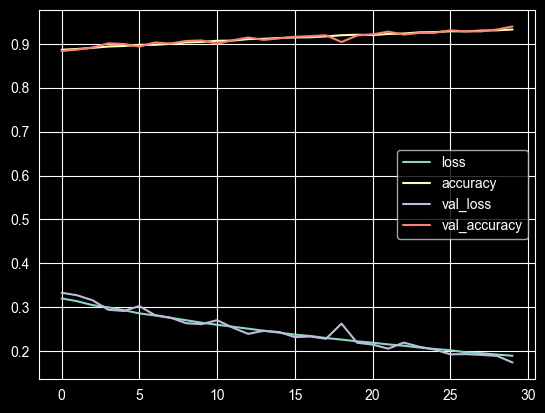

In [49]:
import pandas as pd
pd.DataFrame(history.history).plot()

In [50]:
dd = pd.DataFrame(history.history)
dd

,loss,accuracy,val_loss,val_accuracy
0,0.320334,0.886273,0.333185,0.8834
1,0.313873,0.888018,0.327429,0.8866
2,0.304963,0.890582,0.315872,0.8914
3,0.299998,0.893600,0.294440,0.9008
4,0.293488,0.894855,0.291769,0.8994
5,0.286186,0.897400,0.302916,0.8934
6,0.281568,0.897545,0.282294,0.9028
7,0.276033,0.899691,0.276593,0.9004
8,0.270735,0.903055,0.263914,0.9062
9,0.264975,0.903927,0.261714,0.9074


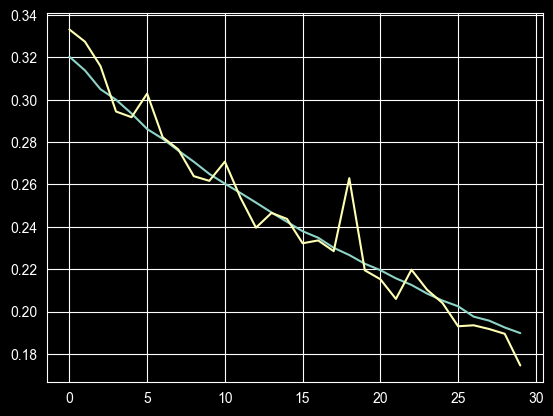

In [51]:
import matplotlib.pyplot as plt
plt.plot(dd["loss"])
plt.plot(dd["val_loss"])


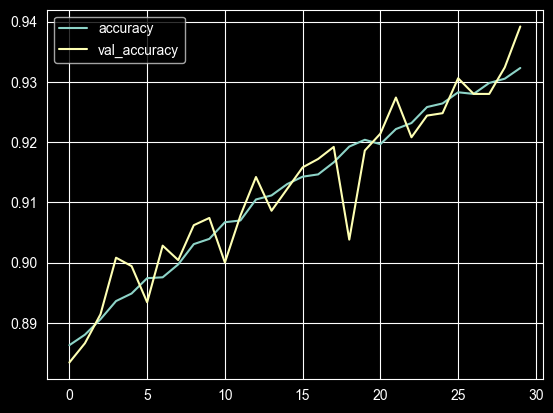

In [52]:
plt.plot(dd["accuracy"],label="accuracy")
plt.plot(dd["val_accuracy"],label="val_accuracy")
plt.legend()

In [53]:
#evaluatiing to see if the modle is readu and is generrlized
model.evaluate(X_test, y_test)

313/313 [==============================] - 0s 1ms/step - loss: 0.3260 - accuracy: 0.8874


[0.32602909207344055, 0.8873999714851379]

Yes, **almost exactly**, but one important correction:

You don't tune the model simply by comparing **training vs validation performance**. You use the **validation set to choose/tune your model and hyperparameters**, while the training set is used to **learn the weights**.

The workflow is:

```text
TRAINING SET
     ↓
learn weights
     ↓
VALIDATION SET
     ↓
evaluate → tune hyperparameters/model
     ↓
choose final model
     ↓
TEST SET
     ↓
final evaluation ONLY
```

For example:

```text
Model A → validation accuracy = 92%
Model B → validation accuracy = 94%
Model C → validation accuracy = 91%

             ↓

Choose Model B
             ↓
Evaluate Model B ONCE on test set
             ↓
Test accuracy = 93%
```

### What you should NOT do

Don't do:

```text
Test accuracy = 90%
        ↓
change hyperparameters
        ↓
Test again = 93%
        ↓
change hyperparameters
        ↓
Test again = 95%
```

Because now you're **tuning to the test set**. Your test set is no longer an unbiased estimate of how the model performs on unseen data.

### The three sets

| Dataset        | Purpose                      |
| -------------- | ---------------------------- |
| **Training**   | Learn model weights          |
| **Validation** | Choose model/hyperparameters |
| **Test**       | Final unbiased evaluation    |

So your understanding is right:

> **Train → tune using validation → freeze the choices → evaluate once on test.**

And that's why the book says **don't tweak hyperparameters based on test performance**.


Yes — **that is the standard idea in both traditional ML and deep learning.**

```text
Training set
   ↓
Learn the model's parameters/weights
   ↓
Validation set
   ↓
Tune hyperparameters + choose model
   ↓
Freeze everything
   ↓
Test set
   ↓
Estimate generalization performance
```

### What each one means

* **Training set:** the model **learns from it** (weights).
* **Validation set:** you use it to **make decisions** — hyperparameters, architecture, regularization, number of epochs, etc.
* **Test set:** you **don't make decisions from it**. You use it at the end to answer:

  > "How well do I expect this model to perform on genuinely unseen data?"

So your phrase **"test is for seeing generalization"** is exactly right.

One small correction to **"be ready for implementation"**: the test set itself doesn't make the model ready for implementation. Rather, **after you've finalized the model and evaluated it on the test set**, you have an unbiased estimate of its expected performance and can then deploy it if the result is satisfactory.

For example:

```text
Train      → learn
Validation → tune
Test       → final evaluation
Deploy     → use in the real world
```

And this applies to **ML, deep learning, CNNs, NLP models, etc.** The exact workflow can vary (e.g., cross-validation, nested CV, time-series splits), but the fundamental principle is the same.


In [54]:
# prediction

In [57]:
X_new = X_test[:3]
y_pred = model.predict(X_new)
y_pred.round(2)

1/1 [==============================] - 0s 16ms/step


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.01, 0.  , 0.99],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

In [58]:
X_new = X_test[:3]

y_pred = model.predict(X_new)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test[:3]

from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes))

1/1 [==============================] - 0s 31ms/step
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



## Now Regression with Keras

In [59]:
from sklearn.datasets import  fetch_california_housing
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [60]:
X ,y = fetch_california_housing(return_X_y=True)

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape[1:]

(8,)

In [62]:
#normalizing
norm_layer  = tf.keras.layers.Normalization(input_shape=X_train.shape[1:])

In [63]:
norm_layer.adapt(X_train)

So your understanding should be:

input_shape → tells the layer what the features look like.
adapt(X_train) → learns how to normalize those features.
When data goes through the layer → it actually gets normalized.

In [65]:
model = tf.keras.Sequential([
    norm_layer,
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(1),
])
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 normalization (Normalizati  (None, 8)                 17        
 on)                                                             
                                                                 
 dense_6 (Dense)             (None, 50)                450       
                                                                 
 dense_7 (Dense)             (None, 50)                2550      
                                                                 
 dense_8 (Dense)             (None, 50)                2550      
                                                                 
 dense_9 (Dense)             (None, 1)                 51        
                                                                 
Total params: 5618 (21.95 KB)
Trainable params: 5601 (21.88 KB)
Non-trainable params: 17 (72.00 Byte)
__________________

In [66]:
model.compile(loss = 'mse',optimizer='adam',metrics=['mse'])

In [67]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_split=0.1
)

Epoch 1/20
465/465 [==============================] - 2s 2ms/step - loss: 0.8046 - mse: 0.8046 - val_loss: 0.4873 - val_mse: 0.4873
Epoch 2/20
465/465 [==============================] - 1s 2ms/step - loss: 0.4087 - mse: 0.4087 - val_loss: 0.4345 - val_mse: 0.4345
Epoch 3/20
465/465 [==============================] - 1s 2ms/step - loss: 0.3602 - mse: 0.3602 - val_loss: 0.3834 - val_mse: 0.3834
Epoch 4/20
465/465 [==============================] - 1s 2ms/step - loss: 0.3517 - mse: 0.3517 - val_loss: 0.3639 - val_mse: 0.3639
Epoch 5/20
465/465 [==============================] - 1s 2ms/step - loss: 0.3330 - mse: 0.3330 - val_loss: 0.3580 - val_mse: 0.3580
Epoch 6/20
465/465 [==============================] - 1s 2ms/step - loss: 0.3206 - mse: 0.3206 - val_loss: 0.3743 - val_mse: 0.3743
Epoch 7/20
465/465 [==============================] - 1s 2ms/step - loss: 0.3240 - mse: 0.3240 - val_loss: 0.3402 - val_mse: 0.3402
Epoch 8/20
465/465 [==============================] - 1s 2ms/step - loss: 0.

In [68]:
model.evaluate(X_test, y_test)

129/129 [==============================] - 0s 1ms/step - loss: 0.2807 - mse: 0.2807


[0.2807285189628601, 0.2807285189628601]

In [69]:
# predict
X_new = X_test[10]
y_pred = model.predict(X_new)
print(y_test[10])
y_pred



1/1 [==============================] - 0s 47ms/step
1.232


array([[1.0246942]], dtype=float32)